# home price prediction model


In [115]:
# dependencies

import pandas as pd
import numpy as np
#from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score , mean_squared_error
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns


In [116]:
df = pd.read_csv("/content/house_price_regression_dataset.csv")

In [117]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [119]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [120]:
df.isnull().sum()

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


In [121]:
df["House_Price"] = df["House_Price"].astype(int)

In [122]:
# df.boxplot(column='House_Price')

In [123]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,262382
1,4272,3,3,2016,4.753014,1,6,985260
2,3592,1,2,2016,3.634823,0,9,777977
3,966,1,2,1977,2.730667,1,8,229698
4,4926,2,1,1993,4.699073,0,8,1041740


In [124]:
scaler = StandardScaler()

# df[['Square_Footage','Num_Bedrooms', 'Num_Bathrooms','Lot_Size', 'Year_Built', 'Garage_Size', 'Neighborhood_Quality']] = scaler.fit_transform(
#     df[['Square_Footage','Num_Bedrooms', 'Num_Bathrooms','Lot_Size', 'Year_Built', 'Garage_Size', 'Neighborhood_Quality']]
# )

In [125]:
X = df[['Square_Footage','Num_Bedrooms','Num_Bathrooms','Year_Built','Lot_Size','Garage_Size','Neighborhood_Quality']]
y = np.log1p(df['House_Price'])
# y = df['House_Price']


In [126]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [127]:
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

In [128]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [129]:
y_pred = model.predict(X_test)
#y_pred = np.expm1(y_pred)

In [130]:
# print(X_train)
# print(y_train)

In [140]:
mae = mean_absolute_error(y_test, y_pred)
accuracy = r2_score(y_test, y_pred) * 100
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("Accuracy (R²): " ,accuracy)

MAE: 0.0907826922079239
R2: 0.9462494725232167
MSE: 0.012923066868728562
Accuracy (R²):  94.62494725232166


In [132]:
print("MSE:", mean_squared_error(y_test, y_pred))

MSE: 0.012923066868728562


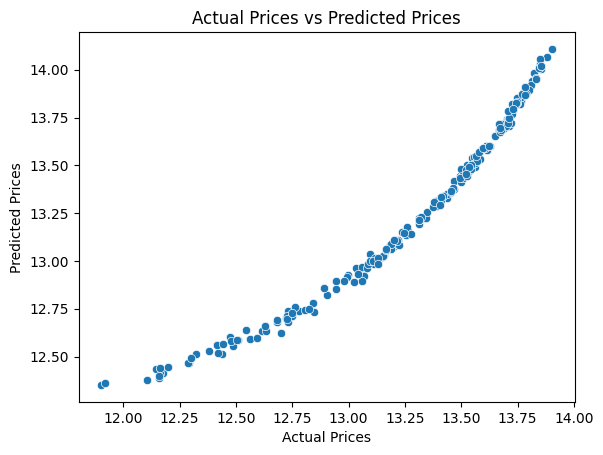

In [133]:
sns.scatterplot(x=y_test, y=y_pred)
# plt.plot(X_test , model.Predict(X_test), color='red')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")

plt.show()

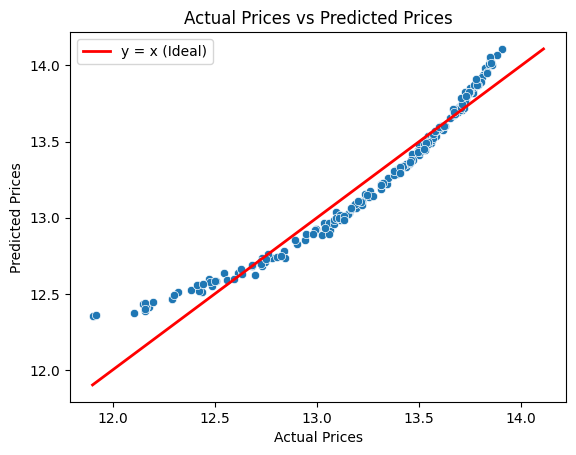

In [134]:
sns.scatterplot(x=y_test, y=y_pred)

# Ideal line y = x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='red',
    linewidth=2,
    label='y = x (Ideal)'
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")
plt.legend()
plt.show()

### model exporting


In [135]:
# import joblib

# joblib.dump(model, "house_price_model.pkl")
# joblib.dump(scaler, "scaler.pkl")

In [136]:
# !ls

In [137]:
# from google.colab import files

# files.download("house_price_model.pkl")
# files.download("scaler.pkl")
